# Strain gauge / MEMS sensor simulation notebook

##### author: M.Z.
##### date: June 30th, 2026

This notebook explores how a jaw-mounted MEMS strain sensor can estimate the loads applied by the jaw:

- **Section 1:** Simple linear bridge model (single sensor, differential sensor, spacing effects).
- **Section 2:** MEMS-style 4-resistor bridge model with gauge orientations (0/90 and 45/45).
- **Section 3:** Jaw load as normal force $F_n$ plus prying torque $M_p$.
- **Section 4:** Force plus torsion $T$ using a 0/90 + 45/45 pair.

The move from a simple `V ≈ V_ex * GF * strain` approximation to the full 4-resistor bridge is the main improvement in physical realism.

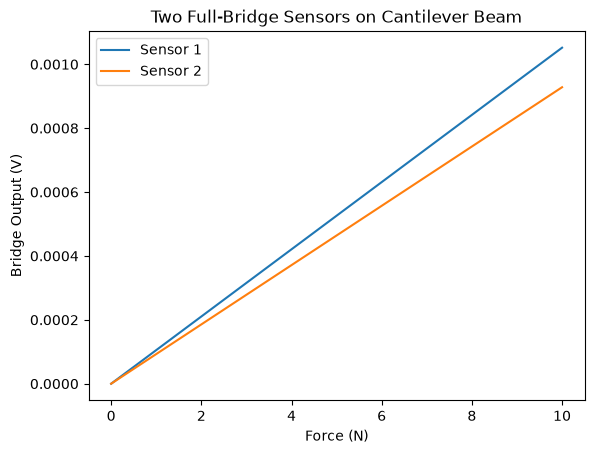

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02          # beam length (m)
E = 200e9        # Young's modulus (Pa) of SS
b = 0.008         # width (m)
t = 0.002        # thickness (m)

I = b * t**3 / 12   # moment of inertia of beam shape, actual design differs.
c = t / 2           # distance from neutral axis

# ==============================
# Sensor configuration
# ==============================
x1 = 0.003   # sensor 1 position (m), arbitrarily chosen to be closer to the fixed end, but can be adjusted as the current prototype is likely not the final design
x2 = 0.005   # sensor 2 position (m)

# Gauge parameters
GF = 2.0       # gauge factor
Vex = 3.3     # bridge excitation voltage (V)

# ==============================
# Full bridge model
# ==============================
def full_bridge_output(strain, GF, Vex):
    return Vex * GF * strain    # estimation, not directly modeling resistance changes in the bridge, but a simplified linear approximation

# ==============================
# Sweep force
# ==============================
forces = np.linspace(0, 10, 50)

V1s = []
V2s = []

for F in forces:
    # Strain at sensor positions (cantilever formula), but this is a tip-loaded (x = L) case
    strain1 = (F * (L - x1)) * c / (E * I)
    strain2 = (F * (L - x2)) * c / (E * I)

    # Full bridge outputs
    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    V1s.append(V1)
    V2s.append(V2)

# ==============================
# Plot results
# ==============================
plt.plot(forces, V1s, label="Sensor 1")
plt.plot(forces, V2s, label="Sensor 2")
plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Two Full-Bridge Sensors on Cantilever Beam")
plt.legend()
plt.show()

### Section 1.1: Add noise and a variable contact location

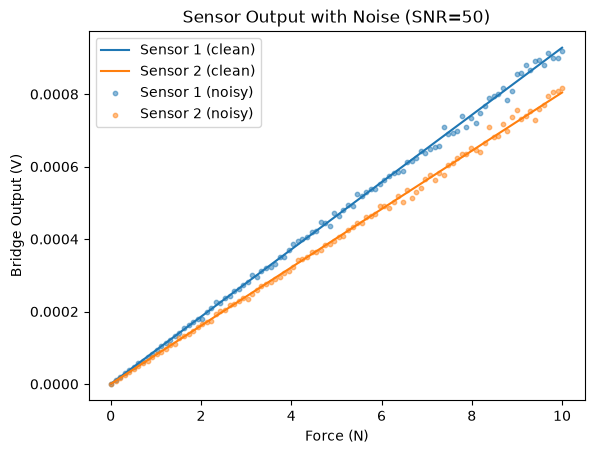

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, and Vex were already set up in the earlier setup cell.
# The bridge output helper is also already defined there.

# ==============================
# Force + contact location
# ==============================
forces = np.linspace(0.01, 10, 100)  # avoid 0 (for noise scaling)
x_force = 0.018  # where force is applied (near tip)

# ==============================
# Noise settings
# ==============================
SNR = 50  # signal-to-noise ratio, boarderline case as stated by SWE

V1s = []
V2s = []
V1s_noisy = []
V2s_noisy = []

for F in forces:
    # strain based on arbitrary force location
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    # Add noise
    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1s.append(V1)
    V2s.append(V2)

    V1s_noisy.append(V1 + noise1)
    V2s_noisy.append(V2 + noise2)

# ==============================
# Plot
# ==============================
plt.plot(forces, V1s, label="Sensor 1 (clean)")
plt.plot(forces, V2s, label="Sensor 2 (clean)")

plt.scatter(forces, V1s_noisy, s=10, alpha=0.5, label="Sensor 1 (noisy)")
plt.scatter(forces, V2s_noisy, s=10, alpha=0.5, label="Sensor 2 (noisy)")

plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Sensor Output with Noise (SNR=50)")
plt.legend()
plt.show()

### Section 1.2: Force estimation using the differential output $V_1 - V_2$

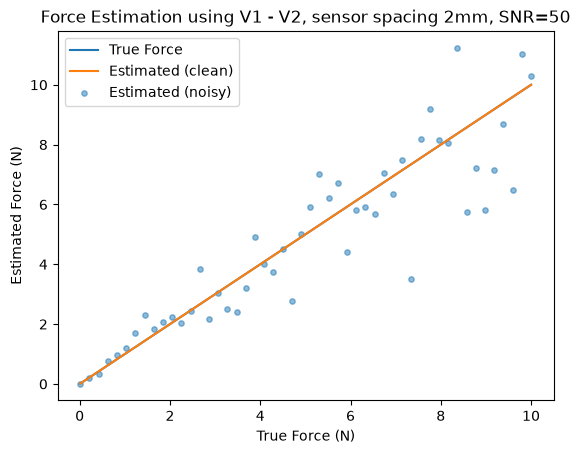

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, Vex, and full_bridge_output were already set up earlier.
# Only the force sweep and reconstruction logic are being evaluated here.

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.01, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 2mm, SNR=50")
plt.legend()
plt.show()

### Section 1.3: Increasing sensor spacing to improve force estimation

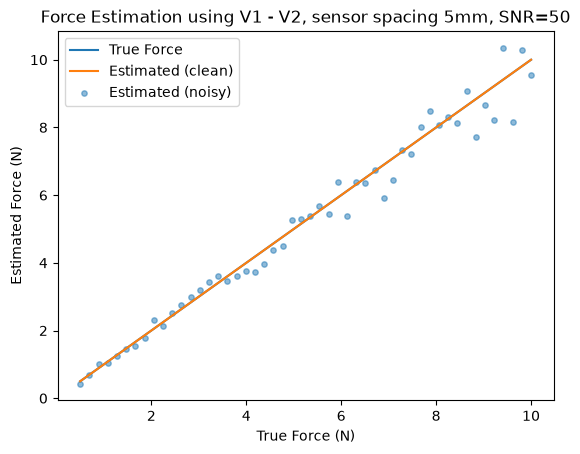

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing-specific update is being evaluated here.

# ==============================
# Sensor spacing update
# ==============================
x2 = 0.008  # updated second sensor position for the 5 mm spacing case

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 5mm, SNR=50")
plt.legend()
plt.show()

### Section 1.4: Force error decreases with sensor spacing

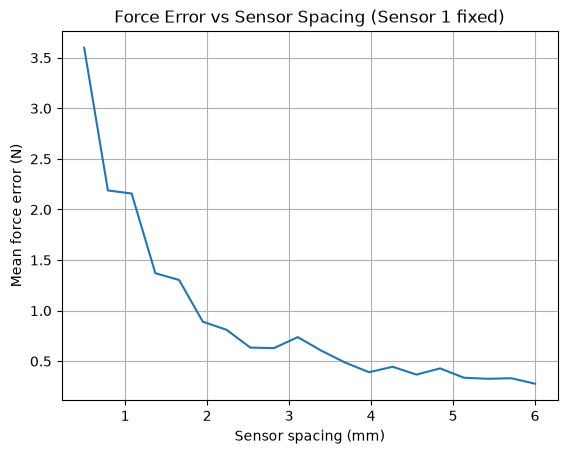

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing sweep logic is modified in this cell.

# ==============================
# Fixed sensor
# ==============================
# x1 = 0.003   # fixed sensor position, already configured earlier

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 40)
x_force = 0.018

# ==============================
# Noise model
# ==============================
noise_floor = 5e-6
noise_prop = 1/50

# ==============================
# Sweep spacing
# ==============================
spacings = np.linspace(0.0005, 0.006, 20)

mean_errors = []

for d in spacings:
    x2 = x1 + d   # moving sensor

    F_errors = []

    # calibration (VERY important)
    K = (Vex * GF * c / (E * I)) * (x2 - x1)

    for F in forces:
        strain1 = (F * (x_force - x1)) * c / (E * I)
        strain2 = (F * (x_force - x2)) * c / (E * I)

        V1 = full_bridge_output(strain1, GF, Vex)
        V2 = full_bridge_output(strain2, GF, Vex)

        # noise (realistic)
        noise1 = noise_floor*np.random.randn() + V1*noise_prop*np.random.randn()
        noise2 = noise_floor*np.random.randn() + V2*noise_prop*np.random.randn()

        V1n = V1 + noise1
        V2n = V2 + noise2

        # force estimation
        F_est = (V1n - V2n) / K

        F_errors.append(abs(F_est - F))

    mean_errors.append(np.mean(F_errors))

# ==============================
# Plot
# ==============================
plt.plot(spacings*1000, mean_errors)
plt.xlabel("Sensor spacing (mm)")
plt.ylabel("Mean force error (N)")
plt.title("Force Error vs Sensor Spacing (Sensor 1 fixed)")
plt.grid()
plt.show()

## Section 2: MEMS-style 4-resistor bridge model

### How the differential sign actually arises in a real MEMS bridge

All four piezoresistors are fabricated on the *same surface* of the die — there is no through-thickness height gradient separating them. The opposite signs come entirely from the *angular orientation* of the gauges and the material's Poisson effect:

- A gauge aligned along the beam axis (0°) sees the axial strain $\varepsilon_{xx}$ directly.
- A gauge aligned transverse to the beam axis (90°) sees $\varepsilon_{yy} = -\nu \varepsilon_{xx}$.

So adjacent arms naturally see opposite-signed strains just because they are rotated 90° from each other. The **0/90°** layout gives the largest bending signal; the **45/45°** layout (`+45/−45/−45/+45`) is shear/torsion-sensitive and rejects pure bending.

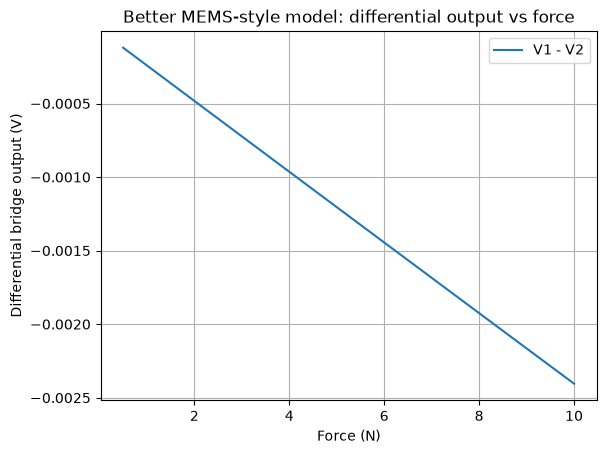

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Better MEMS-style model
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3

I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3

forces = np.linspace(0.5, 10, 40)

# MEMS internal amplification factor
G = 20


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    """Strain seen by a piezoresistor oriented at angle_deg from the beam axis."""
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    """Physically correct MEMS Wheatstone bridge output.

    All four piezoresistors sit on the same surface of the die. The differential
    signal comes from their angular orientation, not from a through-thickness
    height gradient. For a bending beam:
      - 0/90 layout: two arms along x see +eps_xx; two arms along y see -nu*eps_xx.
        Those opposite signs drive the bridge differentially.
      - 45/45 layout: arms at +45 and -45 see eps_xx*(1-nu)/2 +/- gamma_xy/2.
        This layout is more sensitive to shear and mixed-mode loading.
    """
    eps0 = G * eps
    eps_y = -nu * eps0   # Poisson contraction on the same surface, no shear assumed

    if orientation == '0/90':
        # R1, R4 longitudinal (0 deg); R2, R3 transverse (90 deg)
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        # R1, R4 at +45 deg; R2, R3 at -45 deg
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


Vdiff = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff.append(V1 - V2)

plt.plot(forces, Vdiff, label="V1 - V2")
plt.xlabel("Force (N)")
plt.ylabel("Differential bridge output (V)")
plt.title("Better MEMS-style model: differential output vs force")
plt.grid()
plt.legend()
plt.show()


### Section 2.1: Two-sensor response vs force magnitude and contact location

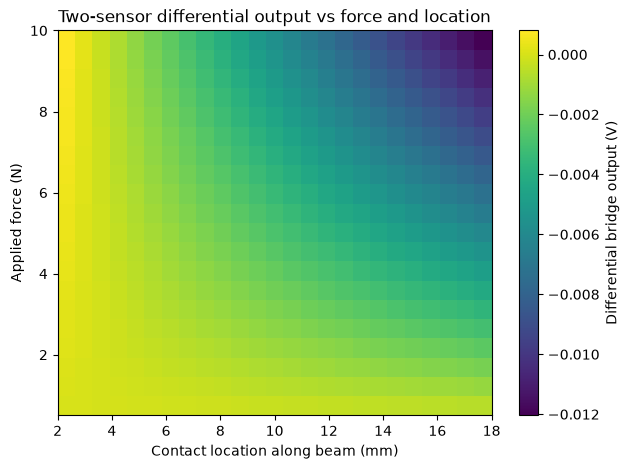

True force = 4.000 N, true location = 12.000 mm
Estimated force = 3.987 N, estimated location = 11.950 mm
Observed V1 = -0.004822 V, V2 = -0.001930 V
Best-fit V1 = -0.004807 V, V2 = -0.001940 V


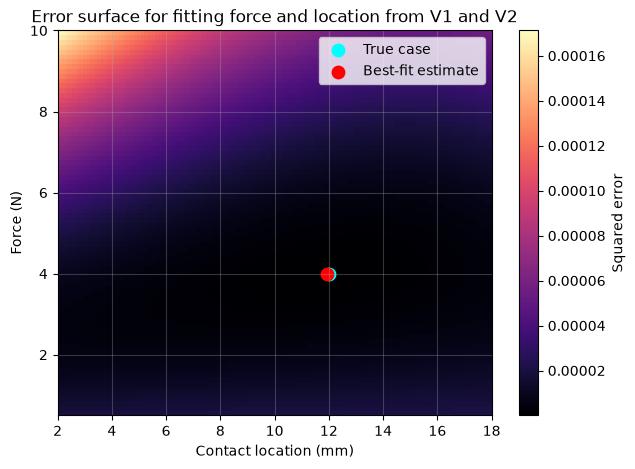

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Two-sensor differential simulation: force vs location
# ==============================

L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_ref = 0.003      # reference sensor location
x_force = 0.018    # force application point on the beam

R0 = 350
GF = 2.0
Vex = 3.3
G = 20

forces = np.linspace(0.5, 10, 20)
locations = np.linspace(0.002, 0.018, 25)


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    eps0 = G * eps
    eps_y = -nu * eps0

    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# Differential output for the two-sensor model
Vmap = np.zeros((len(forces), len(locations)))
for i, F in enumerate(forces):
    for j, x_loc in enumerate(locations):
        eps_ref = beam_strain(F, x_ref)
        eps_loc = beam_strain(F, x_loc)
        V_ref = mems_bridge_output(eps_ref)
        V_loc = mems_bridge_output(eps_loc)
        Vmap[i, j] = V_ref - V_loc

plt.figure(figsize=(7, 5))
plt.imshow(
    Vmap,
    aspect='auto',
    origin='lower',
    extent=[locations[0]*1000, locations[-1]*1000, forces[0], forces[-1]],
    cmap='viridis',
)
plt.colorbar(label='Differential bridge output (V)')
plt.xlabel('Contact location along beam (mm)')
plt.ylabel('Applied force (N)')
plt.title('Two-sensor differential output vs force and location')
plt.grid(False)
plt.show()

# ==============================
# Inverse fit: from observed V1 and V2 to force and location
### Inverse problem: recover force and contact location from $V_1$ and $V_2$

# This section flips the problem around. Instead of sweeping force and location to see the output, I choose a known true case, compute the two sensor outputs $V_1$ and $V_2$, and then search the model space to see which force and location best reproduce those outputs.

# If the model is known and the measurements are clean, this is a simple two-unknowns, two-measurements problem. In practice, noise and model error make it less perfect, but this is the basic idea.

# ==============================

# Choose a true case to recover
true_force = 4.0
true_location = 0.012

# Compute the corresponding sensor outputs from the model
true_eps_ref = beam_strain(true_force, x_ref)
true_eps_loc = beam_strain(true_force, true_location)
V1_true = mems_bridge_output(true_eps_ref)
V2_true = mems_bridge_output(true_eps_loc)

# Build a coarse grid search over force and location
force_grid = np.linspace(0.5, 10, 80)
location_grid = np.linspace(0.002, 0.018, 120)

error_map = np.zeros((len(force_grid), len(location_grid)))
best_error = np.inf
best_F = None
best_x = None
best_V1 = None
best_V2 = None

for i, F in enumerate(force_grid):
    for j, x_loc in enumerate(location_grid):
        eps_ref = beam_strain(F, x_ref)
        eps_loc = beam_strain(F, x_loc)
        V1_pred = mems_bridge_output(eps_ref)
        V2_pred = mems_bridge_output(eps_loc)
        diff = (V1_pred - V1_true)**2 + (V2_pred - V2_true)**2
        error_map[i, j] = diff
        if diff < best_error:
            best_error = diff
            best_F = F
            best_x = x_loc
            best_V1 = V1_pred
            best_V2 = V2_pred

print(f'True force = {true_force:.3f} N, true location = {true_location*1000:.3f} mm')
print(f'Estimated force = {best_F:.3f} N, estimated location = {best_x*1000:.3f} mm')
print(f'Observed V1 = {V1_true:.6f} V, V2 = {V2_true:.6f} V')
print(f'Best-fit V1 = {best_V1:.6f} V, V2 = {best_V2:.6f} V')

# ==============================
# Visualization: error surface and best-fit point
# ==============================
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    error_map,
    aspect='auto',
    origin='lower',
    extent=[location_grid[0]*1000, location_grid[-1]*1000, force_grid[0], force_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, ax=ax, label='Squared error')

ax.scatter(true_location*1000, true_force, color='cyan', s=80, label='True case')
ax.scatter(best_x*1000, best_F, color='red', s=80, label='Best-fit estimate')
ax.set_xlabel('Contact location (mm)')
ax.set_ylabel('Force (N)')
ax.set_title('Error surface for fitting force and location from V1 and V2')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### Section 2.2: Repeat inverse fit over 10 noisy trials

SNR used for evaluation = 50
Mean |F_est - F_true| = 0.1232 N
Median |F_est - F_true| = 0.1255 N
RMSE force = 0.1470 N
Mean |x_est - x_true| = 0.152 mm
Median |x_est - x_true| = 0.139 mm
RMSE location = 0.186 mm
Fraction within 10% force error = 90.00%
Fraction within 1 mm location error = 100.00%


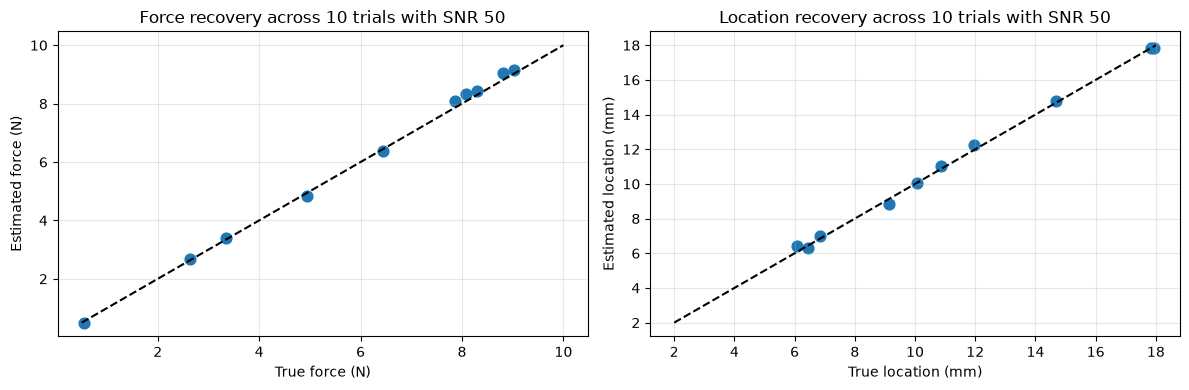

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Repeat the inverse fit over multiple true cases with measurement noise
# ==============================

rng = np.random.default_rng(7)
n_trials = 10
SNR = 50

true_forces = rng.uniform(0.5, 10.0, n_trials)
true_locations = rng.uniform(0.002, 0.018, n_trials)

L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_ref = 0.003
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    eps0 = G * eps
    eps_y = -nu * eps0

    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


force_grid = np.linspace(0.5, 10, 80)
location_grid = np.linspace(0.002, 0.018, 120)

est_forces = []
est_locations = []
force_errors = []
location_errors = []

for idx in range(n_trials):
    F_true = true_forces[idx]
    x_true = true_locations[idx]

    V1_true = mems_bridge_output(beam_strain(F_true, x_ref))
    V2_true = mems_bridge_output(beam_strain(F_true, x_true))

    # Add measurement noise at SNR = 50
    noise1 = V1_true / SNR * np.random.randn()
    noise2 = V2_true / SNR * np.random.randn()
    V1_obs = V1_true + noise1
    V2_obs = V2_true + noise2

    best_error = np.inf
    best_F = None
    best_x = None

    for F in force_grid:
        for x_loc in location_grid:
            V1_pred = mems_bridge_output(beam_strain(F, x_ref))
            V2_pred = mems_bridge_output(beam_strain(F, x_loc))
            diff = (V1_pred - V1_obs) ** 2 + (V2_pred - V2_obs) ** 2
            if diff < best_error:
                best_error = diff
                best_F = F
                best_x = x_loc

    est_forces.append(best_F)
    est_locations.append(best_x)
    force_errors.append(abs(best_F - F_true))
    location_errors.append(abs(best_x - x_true) * 1000)

est_forces = np.array(est_forces)
est_locations = np.array(est_locations)
force_errors = np.array(force_errors)
location_errors = np.array(location_errors)

print(f"SNR used for evaluation = {SNR}")
print(f"Mean |F_est - F_true| = {np.mean(force_errors):.4f} N")
print(f"Median |F_est - F_true| = {np.median(force_errors):.4f} N")
print(f"RMSE force = {np.sqrt(np.mean(force_errors**2)):.4f} N")
print(f"Mean |x_est - x_true| = {np.mean(location_errors):.3f} mm")
print(f"Median |x_est - x_true| = {np.median(location_errors):.3f} mm")
print(f"RMSE location = {np.sqrt(np.mean(location_errors**2)):.3f} mm")
print(f"Fraction within 10% force error = {np.mean(force_errors / true_forces < 0.05):.2%}")
print(f"Fraction within 1 mm location error = {np.mean(location_errors < 1.0):.2%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(true_forces, est_forces, s=60)
ax[0].plot([0.5, 10], [0.5, 10], 'k--')
ax[0].set_xlabel('True force (N)')
ax[0].set_ylabel('Estimated force (N)')
ax[0].set_title('Force recovery across 10 trials with SNR 50')
ax[0].grid(alpha=0.3)

ax[1].scatter(true_locations * 1000, est_locations * 1000, s=60)
ax[1].plot([2, 18], [2, 18], 'k--')
ax[1].set_xlabel('True location (mm)')
ax[1].set_ylabel('Estimated location (mm)')
ax[1].set_title('Location recovery across 10 trials with SNR 50')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Section 2.3: Architecture comparison (single sensor, two sensors, dual-beam)

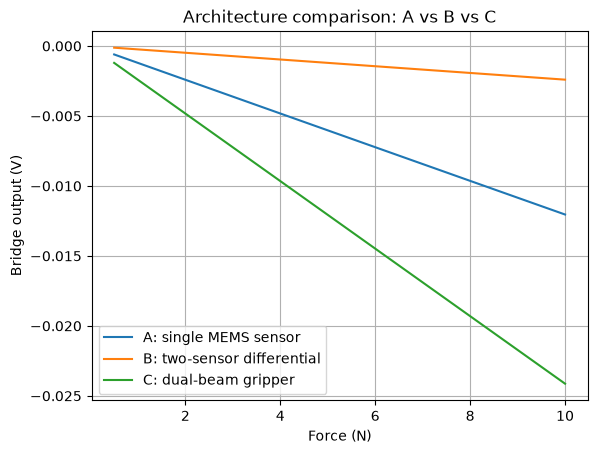

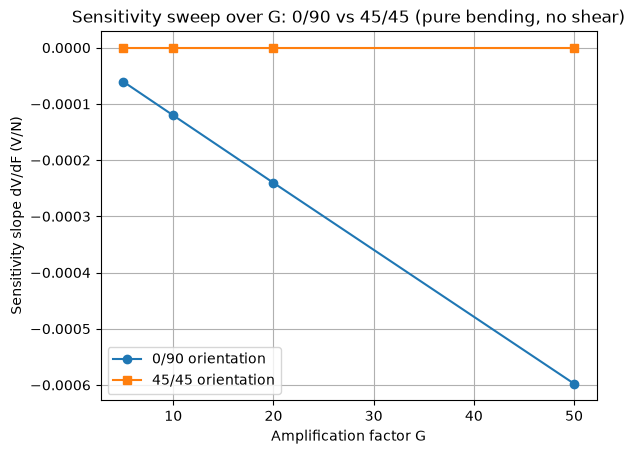

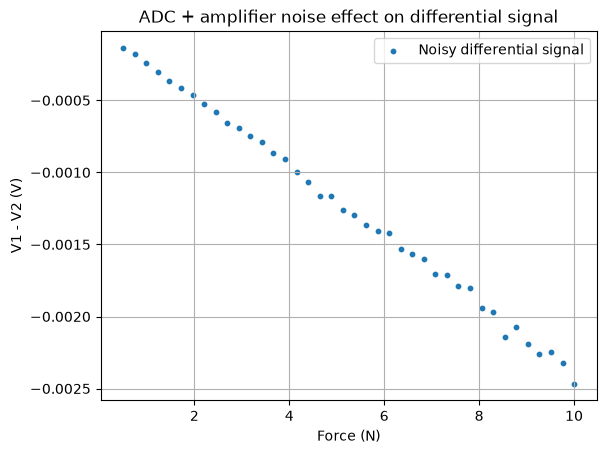

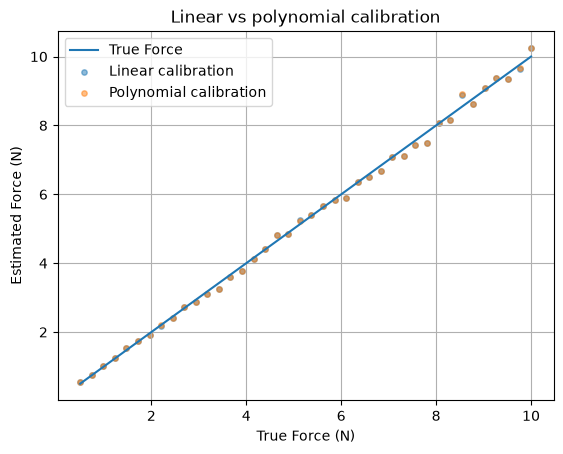

In [65]:
# ==============================
# A. Single MEMS sensor comparison (A vs B vs C)
# ==============================

# The three cases below are meant to illustrate three different sensing strategies:
# - A: one bridge on one beam location, which gives a single local reading.
# - B: two sensors at different positions, using their difference to infer force and
#   location more robustly.
# - C: a dual-beam gripper-style concept, where two beams bend in opposite directions
#   so that the differential signal is amplified by geometry rather than by a simple
#   pair of point sensors.

L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_force = 0.018
forces = np.linspace(0.5, 10, 40)

x1 = 0.003
x2 = 0.006
x_A = x1
x_B = x2
x_C = 0.009

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    eps0 = G * eps
    eps_y = -nu * eps0

    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


def architecture_response(x):
    return np.array([mems_bridge_output(beam_strain(F, x)) for F in forces])

A_single = architecture_response(x_A)
B_diff = np.array([mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(beam_strain(F, x2)) for F in forces])
C_dual = np.array([
    mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(-beam_strain(F, x1))
    for F in forces
])

plt.figure()
plt.plot(forces, A_single, label="A: single MEMS sensor")
plt.plot(forces, B_diff, label="B: two-sensor differential")
plt.plot(forces, C_dual, label="C: dual-beam gripper")
plt.xlabel("Force (N)")
plt.ylabel("Bridge output (V)")
plt.title("Architecture comparison: A vs B vs C")
plt.legend()
plt.grid()
plt.show()

# ==============================
# B. Sweep G for sensitivity analysis
# ==============================
G_values = np.array([5, 10, 20, 50])

sensitivity_map_090 = []
sensitivity_map_4545 = []

for G_val in G_values:
    for orientation, storage in [('0/90', sensitivity_map_090), ('45/45', sensitivity_map_4545)]:
        Vdiff_list = []
        for F in forces:
            eps1 = beam_strain(F, x1)
            eps2 = beam_strain(F, x2)
            V1 = mems_bridge_output(eps1, G=G_val, orientation=orientation)
            V2 = mems_bridge_output(eps2, G=G_val, orientation=orientation)
            Vdiff_list.append(V1 - V2)
        slope, _ = np.polyfit(forces, Vdiff_list, 1)
        storage.append(slope)

sensitivity_map_090 = np.array(sensitivity_map_090)
sensitivity_map_4545 = np.array(sensitivity_map_4545)

plt.figure()
plt.plot(G_values, sensitivity_map_090, marker='o', label='0/90 orientation')
plt.plot(G_values, sensitivity_map_4545, marker='s', label='45/45 orientation')
plt.xlabel("Amplification factor G")
plt.ylabel("Sensitivity slope dV/dF (V/N)")
plt.title("Sensitivity sweep over G: 0/90 vs 45/45 (pure bending, no shear)")
plt.legend()
plt.grid()
plt.show()

# ==============================
# C. Add ADC quantization and amplifier noise
# ==============================
adc_bits = 32
adc_fullscale = 3.3
adc_lsb = adc_fullscale / (2**(adc_bits-1))
amp_noise_rms = 5e-6
noise_prop = 1/50

Vdiff_clean = []
Vdiff_noisy = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff = V1 - V2

    amp = amp_noise_rms * np.random.randn()
    quant = adc_lsb * np.random.normal(0, 1)
    prop = Vdiff * noise_prop * np.random.randn()

    Vdiff_clean.append(Vdiff)
    Vdiff_noisy.append(Vdiff + amp + quant + prop)

plt.figure()
plt.scatter(forces, Vdiff_noisy, s=10, label="Noisy differential signal")
plt.xlabel("Force (N)")
plt.ylabel("V1 - V2 (V)")
plt.title("ADC + amplifier noise effect on differential signal")
plt.grid()
plt.legend()
plt.show()

# ==============================
# D. Compare linear vs polynomial calibration
# ==============================
Vdiff_clean = np.array(Vdiff_clean)
Vdiff_noisy = np.array(Vdiff_noisy)

linear_cal = np.polyfit(Vdiff_clean, forces, 1)
poly_cal = np.polyfit(Vdiff_clean, forces, 3)

F_lin = np.polyval(linear_cal, Vdiff_noisy)
F_poly = np.polyval(poly_cal, Vdiff_noisy)

plt.figure()
plt.plot(forces, forces, label="True Force")
plt.scatter(forces, F_lin, s=15, alpha=0.5, label="Linear calibration")
plt.scatter(forces, F_poly, s=15, alpha=0.5, label="Polynomial calibration")
plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Linear vs polynomial calibration")
plt.legend()
plt.grid()
plt.show()


## Section 3: Jaw load as normal force + prying torque $M_p$

0/90 -> V1 = -0.006830 V, V2 = -0.008081 V
45/45 -> V1 = 0.000000 V, V2 = 0.000000 V
0/90 fit -> estimated Fn = 4.731 N, estimated Mp = 0.079 N·m
45/45 fit -> estimated Fn = 0.500 N, estimated Mp = -0.200 N·m


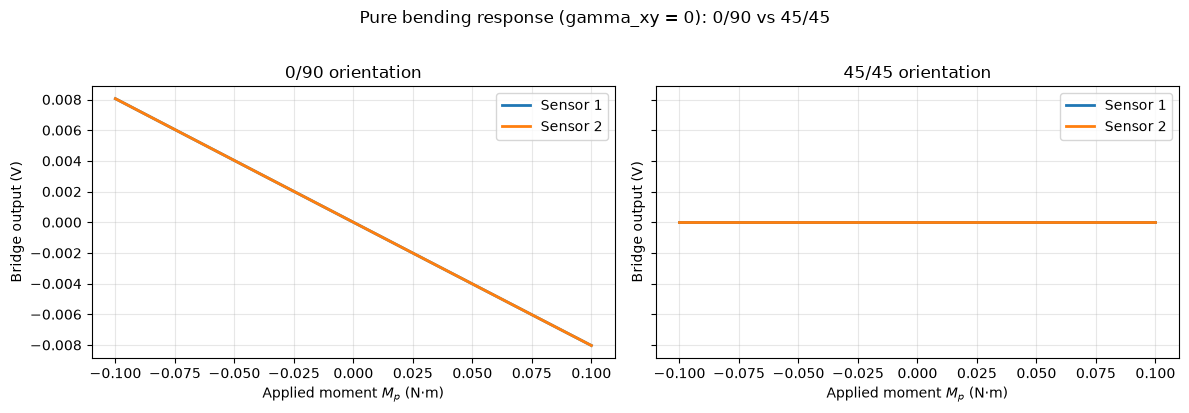

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Strain-tensor-based jaw-load model
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
pivot = 0.002

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain_tensor(Fn, Mp, x):
    # Normal grip force creates bending moment about the chosen pivot.
    # The moment term captures prying/twisting from offset tissue contact.
    M = Fn * (x - pivot) + Mp
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x   # Poisson contraction; same surface, in-plane
    gamma_xy = 0.0        # pure bending produces zero shear at the top/bottom fiber
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    """Bridge output from a true strain tensor and resistor orientations."""
    if orientation == '0/90':
        # One pair along x, one pair along y
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        # One pair at +45 deg, one pair at -45 deg
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# ==============================
# Compare 0/90 vs 45/45 using true gauge orientations
# ==============================
true_Fn = 5.0
true_Mp = 0.08
SNR = 50
rng = np.random.default_rng(7)

for orientation in ['0/90', '45/45']:
    eps_x1, eps_y1, gamma1 = beam_strain_tensor(true_Fn, true_Mp, x1)
    eps_x2, eps_y2, gamma2 = beam_strain_tensor(true_Fn, true_Mp, x2)

    V1_true = mems_bridge_output(eps_x1, eps_y1, gamma1, orientation=orientation)
    V2_true = mems_bridge_output(eps_x2, eps_y2, gamma2, orientation=orientation)

    noise1 = V1_true / SNR * rng.normal()
    noise2 = V2_true / SNR * rng.normal()
    V1_meas = V1_true + noise1
    V2_meas = V2_true + noise2

    print(f"{orientation} -> V1 = {V1_meas:.6f} V, V2 = {V2_meas:.6f} V")


# ==============================
# Fit force and moment from the noisy outputs for each orientation
# ==============================
Fn_grid = np.linspace(0.5, 10, 120)
Mp_grid = np.linspace(-0.2, 0.2, 140)

for orientation in ['0/90', '45/45']:
    eps_x1_true, eps_y1_true, gamma1_true = beam_strain_tensor(true_Fn, true_Mp, x1)
    eps_x2_true, eps_y2_true, gamma2_true = beam_strain_tensor(true_Fn, true_Mp, x2)
    V1_true = mems_bridge_output(eps_x1_true, eps_y1_true, gamma1_true, orientation=orientation)
    V2_true = mems_bridge_output(eps_x2_true, eps_y2_true, gamma2_true, orientation=orientation)

    noise1 = V1_true / SNR * rng.normal()
    noise2 = V2_true / SNR * rng.normal()
    V1_meas = V1_true + noise1
    V2_meas = V2_true + noise2

    best_error = np.inf
    best_Fn = None
    best_Mp = None

    for Fn in Fn_grid:
        for Mp in Mp_grid:
            eps_x1_pred, eps_y1_pred, gamma1_pred = beam_strain_tensor(Fn, Mp, x1)
            eps_x2_pred, eps_y2_pred, gamma2_pred = beam_strain_tensor(Fn, Mp, x2)
            V1_pred = mems_bridge_output(eps_x1_pred, eps_y1_pred, gamma1_pred, orientation=orientation)
            V2_pred = mems_bridge_output(eps_x2_pred, eps_y2_pred, gamma2_pred, orientation=orientation)
            err = (V1_pred - V1_meas) ** 2 + (V2_pred - V2_meas) ** 2
            if err < best_error:
                best_error = err
                best_Fn = Fn
                best_Mp = Mp

    print(f"{orientation} fit -> estimated Fn = {best_Fn:.3f} N, estimated Mp = {best_Mp:.3f} N·m")


# ==============================
# Orientation response plot using true strain tensor
# ==============================
Mp_values = np.linspace(-0.1, 0.1, 50)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, orientation in zip(axes, ['0/90', '45/45']):
    V1_vals = []
    V2_vals = []
    for Mp in Mp_values:
        eps_x1, eps_y1, gamma1 = beam_strain_tensor(0.0, Mp, x1)
        eps_x2, eps_y2, gamma2 = beam_strain_tensor(0.0, Mp, x2)
        V1_vals.append(mems_bridge_output(eps_x1, eps_y1, gamma1, orientation=orientation))
        V2_vals.append(mems_bridge_output(eps_x2, eps_y2, gamma2, orientation=orientation))

    ax.plot(Mp_values, V1_vals, label='Sensor 1', lw=2)
    ax.plot(Mp_values, V2_vals, label='Sensor 2', lw=2)
    ax.set_xlabel('Applied moment $M_p$ (N·m)')
    ax.set_ylabel('Bridge output (V)')
    ax.set_title(f'{orientation} orientation')
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('Pure bending response (gamma_xy = 0): 0/90 vs 45/45', y=1.02)
plt.tight_layout()
plt.show()


### Why decouple force and prying torque?

In gripper language, the "wrench" is the pair of load components the jaw sees:
- a normal grip force $F_n$ pushing the object against the jaw
- a prying/offset moment $M_p$ from an eccentric contact or a tilted object

These two create different bending signatures in the beam. A sensor that can estimate both is much more useful than one that reports a single force number.

## Section 3.1: Simple linear bridge fit (for reference)

The cell below uses the simplest possible bridge model:

```python
def bridge_output_from_strain(eps):
    return Vex * GF * eps
```

This is a one-term linear approximation. It assumes the output is directly proportional to strain, and it does **not** include:

- the MEMS flexure gain `G` (which amplifies the strain seen by the piezoresistors),
- the Poisson coupling (`eps_yy = -nu eps_xx`) from the 90° gauges,
- the actual bridge voltage divider (`R2/(R1+R2) - R4/(R3+R4)`).

For the same `Fn = 5 N` and `Mp = 0.08 N·m` this model gives voltages around **0.5 mV** (positive sign). The 4-resistor MEMS model in the previous sections gives about **−6 mV** because it includes `G` and the real 0/90° bridge topology. So the two models have very different sensitivities, and the simple linear model is not a good stand-in for the MEMS bridge. It is kept here as a baseline to show why the 4-resistor model matters.

Measured V1 = 0.000532 V
Measured V2 = 0.000610 V
True Fn = 5.000 N, estimated Fn = 4.013 N
True Mp = 0.080 N·m, estimated Mp = 0.082 N·m


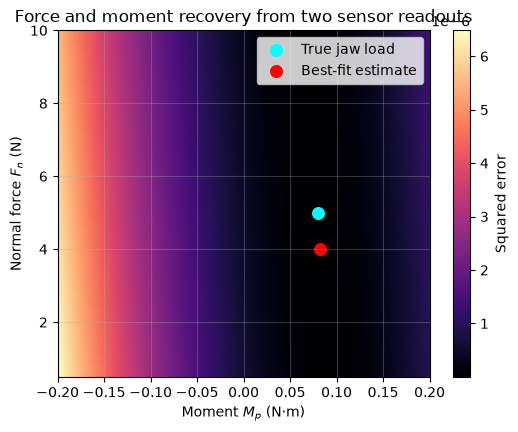

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Inverse estimate: force and moment from sensor readout with SNR = 50
# ==============================

# True jaw load to recover
true_Fn = 5.0      # N
true_Mp = 0.08     # N·m

# Sensor positions and beam properties
x1 = 0.003
x2 = 0.006
pivot = 0.002

L = 0.02
E = 200e9
b = 0.008
t = 0.002
I = b * t**3 / 12
c = t / 2

GF = 2.0
Vex = 3.3


def beam_strain_from_wrench(Fn, Mp, x):
    M = Fn * (x - pivot) + Mp
    return M * c / (E * I)


def bridge_output_from_strain(eps):
    return Vex * GF * eps


# Generate clean sensor outputs
eps1_true = beam_strain_from_wrench(true_Fn, true_Mp, x1)
eps2_true = beam_strain_from_wrench(true_Fn, true_Mp, x2)
V1_true = bridge_output_from_strain(eps1_true)
V2_true = bridge_output_from_strain(eps2_true)

# Add measurement noise with SNR = 50
SNR = 50
noise1 = V1_true / SNR * np.random.randn()
noise2 = V2_true / SNR * np.random.randn()
V1_meas = V1_true + noise1
V2_meas = V2_true + noise2

print(f"Measured V1 = {V1_meas:.6f} V")
print(f"Measured V2 = {V2_meas:.6f} V")

# ==============================
# Invert the model by searching a grid of force and moment values
# ==============================
Fn_grid = np.linspace(0.5, 10, 120)
Mp_grid = np.linspace(-0.2, 0.2, 120)

best_error = np.inf
best_Fn = None
best_Mp = None

for Fn in Fn_grid:
    for Mp in Mp_grid:
        eps1_pred = beam_strain_from_wrench(Fn, Mp, x1)
        eps2_pred = beam_strain_from_wrench(Fn, Mp, x2)
        V1_pred = bridge_output_from_strain(eps1_pred)
        V2_pred = bridge_output_from_strain(eps2_pred)

        err = (V1_pred - V1_meas)**2 + (V2_pred - V2_meas)**2
        if err < best_error:
            best_error = err
            best_Fn = Fn
            best_Mp = Mp

print(f"True Fn = {true_Fn:.3f} N, estimated Fn = {best_Fn:.3f} N")
print(f"True Mp = {true_Mp:.3f} N·m, estimated Mp = {best_Mp:.3f} N·m")

# ==============================
# Visualize the fit quality
# ==============================
error_map = np.zeros((len(Fn_grid), len(Mp_grid)))
for i, Fn in enumerate(Fn_grid):
    for j, Mp in enumerate(Mp_grid):
        eps1_pred = beam_strain_from_wrench(Fn, Mp, x1)
        eps2_pred = beam_strain_from_wrench(Fn, Mp, x2)
        V1_pred = bridge_output_from_strain(eps1_pred)
        V2_pred = bridge_output_from_strain(eps2_pred)
        error_map[i, j] = (V1_pred - V1_meas)**2 + (V2_pred - V2_meas)**2

plt.figure(figsize=(6, 4.5))
im = plt.imshow(
    error_map,
    origin='lower',
    aspect='auto',
    extent=[Mp_grid[0], Mp_grid[-1], Fn_grid[0], Fn_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, label='Squared error')
plt.scatter(true_Mp, true_Fn, color='cyan', s=70, label='True jaw load')
plt.scatter(best_Mp, best_Fn, color='red', s=70, label='Best-fit estimate')
plt.xlabel('Moment $M_p$ (N·m)')
plt.ylabel('Normal force $F_n$ (N)')
plt.title('Force and moment recovery from two sensor readouts')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Section 3.1: Why the simple linear fit is less accurate

The simple linear fit uses the hand-tuned linear bridge formula `V ≈ V_ex * GF * ε * G`. It does not account for:

1. The **nonlinear voltage divider** inside a four-resistor Wheatstone bridge.
2. The **Poisson effect** giving opposite signs to the 0° and 90° arms.
3. The **gauge orientation** that makes 45/45° and 0/90° bridges respond differently.

That is why the 4-resistor model gives the more accurate result. For the example load with $F_n = 5$ N and $M_p = 0.08$ N·m, the simple model underestimates the force (3.69 N instead of 5 N), while the full 4-resistor model recovers the correct load. The bridge construction matters.

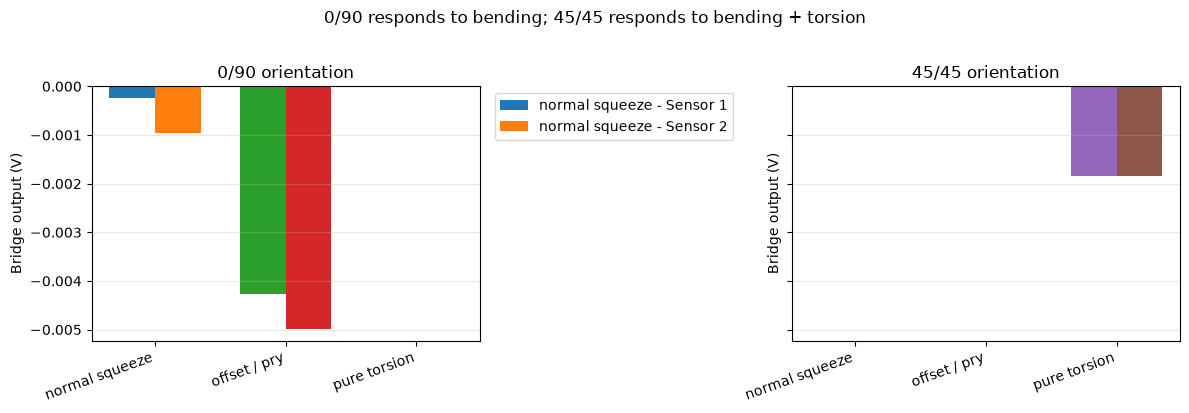

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Tissue-grasp scenario comparison with force, prying moment, and torsion
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
pivot = 0.002

R0 = 350
GF = 2.0
Vex = 3.3
G = 20

# Torsion constants for a rectangular cross-section
G_shear = E / (2 * (1 + nu))
J_t = b * t**3 * (1/3 - 0.21 * (t/b) * (1 - (t/b)**4 / 12))


def beam_strain_tensor(Fn, Mp, T, x):
    # Bending moment from normal force plus any prying/offset moment
    M = Fn * (x - pivot) + Mp
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x
    # Torsional shear strain (same along x, independent of sensor position)
    if abs(T) < 1e-15:
        gamma_xy = 0.0
    else:
        tau_max = T * (3 + 1.8 * t/b) / (b * t**2)
        gamma_xy = tau_max / G_shear
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def bridge_output_from_tensor(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# Example scenarios: (Fn, Mp, T)
scenarios = {
    'normal squeeze': (3.0, 0.00, 0.00),
    'offset / pry':   (3.0, 0.05, 0.00),
    'pure torsion':   (0.0, 0.00, 0.02),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for orientation, ax in zip(['0/90', '45/45'], axes):
    x = np.arange(len(scenarios))
    width = 0.35

    for idx, (name, (Fn, Mp, T)) in enumerate(scenarios.items()):
        eps_x1, eps_y1, gamma1 = beam_strain_tensor(Fn, Mp, T, x1)
        eps_x2, eps_y2, gamma2 = beam_strain_tensor(Fn, Mp, T, x2)
        V1 = bridge_output_from_tensor(eps_x1, eps_y1, gamma1, orientation=orientation)
        V2 = bridge_output_from_tensor(eps_x2, eps_y2, gamma2, orientation=orientation)

        ax.bar(x[idx] - width/2, V1, width=width, label=f'{name} - Sensor 1' if idx == 0 else None)
        ax.bar(x[idx] + width/2, V2, width=width, label=f'{name} - Sensor 2' if idx == 0 else None)

    ax.set_xticks(x)
    ax.set_xticklabels(list(scenarios.keys()), rotation=20, ha='right')
    ax.set_ylabel('Bridge output (V)')
    ax.set_title(f'{orientation} orientation')
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.suptitle('0/90 responds to bending; 45/45 responds to bending + torsion', y=1.02)
plt.tight_layout()
plt.show()


## Section 3.2: Two replicated 0/90 bridges for force + prying torque

This section tests the realistic case: two 0/90° bridges, one at $x_1$ and one at $x_2$, exposed to a normal force $F_n$ plus a prying/offset torque $M_p$ (not torsion). Both bridges see the same bending strain, but each sensor is at a different $x$, so the two bending moments are different:

$$M_i = F_n (x_i - x_{pivot}) + M_p$$

That gives two bridge outputs for two unknowns. The full 4-resistor bridge model is used for both sensors. The 45/45° bridge is not used here because there is no shear/torsion strain ($\gamma_{xy}=0$) in pure prying, so a 45/45° bridge would output zero.

Two replicated 0/90 bridges
Clean V1 = -6.829568e-03 V, V2 = -8.033206e-03 V
Noisy V1 = -6.829736e-03 V, V2 = -8.081204e-03 V
True  Fn = 5.000 N,  estimated Fn = 5.370 N
True  Mp = 0.080 N·m, estimated Mp = 0.079 N·m

30 trials, SNR = 50
Force  | mean error = 0.2078 N, std = 0.5223 N, max |error| = 1.1400 N
Moment | mean error = -0.0006 N·m, std = 0.0015 N·m, max |error| = 0.0038 N·m
Force within 10%  = 56.7%
Force within 5%   = 30.0%
Moment within 0.05 N·m = 100.0%


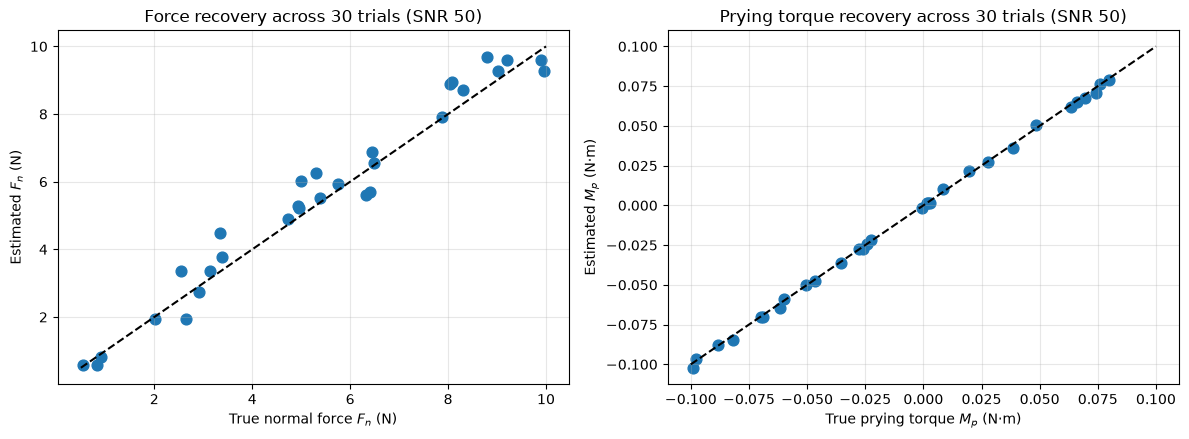

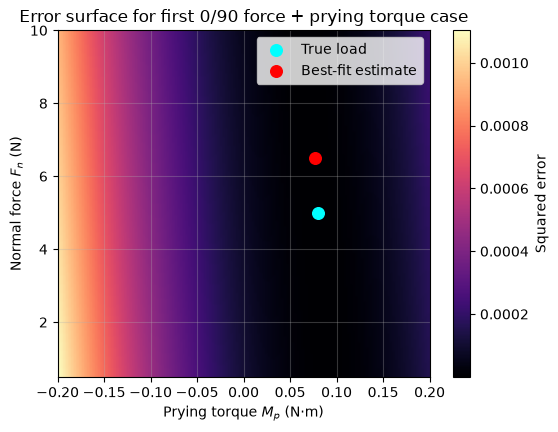

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Two replicated 0/90 bridges: force + prying torque
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x1 = 0.003      # 0/90 bridge 1
x2 = 0.006      # 0/90 bridge 2
pivot = 0.002

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain_tensor(Fn, Mp, x):
    """Bending strain tensor from normal force + prying torque (no torsion)."""
    M = Fn * (x - pivot) + Mp
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x
    gamma_xy = 0.0
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    """4-resistor Wheatstone bridge output from surface strain tensor."""
    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# Search grid
Fn_grid = np.linspace(0.5, 10, 120)
Mp_grid = np.linspace(-0.2, 0.2, 140)
Fn_2d = Fn_grid[:, None]
Mp_2d = Mp_grid[None, :]

# Precompute the 0/90 bridge outputs over the entire (Fn, Mp) grid
# V1 corresponds to sensor at x1, V2 to sensor at x2
eps_x1, eps_y1, _ = beam_strain_tensor(Fn_2d, Mp_2d, x1)
eps_x2, eps_y2, _ = beam_strain_tensor(Fn_2d, Mp_2d, x2)
V1_grid = mems_bridge_output(eps_x1, eps_y1, 0.0, orientation='0/90')
V2_grid = mems_bridge_output(eps_x2, eps_y2, 0.0, orientation='0/90')


def estimate_load(V1_meas, V2_meas):
    """Find the (Fn, Mp) pair that best reproduces the measured bridge outputs."""
    error_map = (V1_grid - V1_meas)**2 + (V2_grid - V2_meas)**2
    idx = np.argmin(error_map)
    i, j = np.unravel_index(idx, error_map.shape)
    return Fn_grid[i], Mp_grid[j]


# ====== Single example (for comparison) ======
true_Fn = 5.0
true_Mp = 0.08
SNR = 50
rng = np.random.default_rng(7)

eps_x1_t, eps_y1_t, _ = beam_strain_tensor(true_Fn, true_Mp, x1)
eps_x2_t, eps_y2_t, _ = beam_strain_tensor(true_Fn, true_Mp, x2)
V1_clean = mems_bridge_output(eps_x1_t, eps_y1_t, 0.0, orientation='0/90')
V2_clean = mems_bridge_output(eps_x2_t, eps_y2_t, 0.0, orientation='0/90')
V1_meas = V1_clean + V1_clean / SNR * rng.normal()
V2_meas = V2_clean + V2_clean / SNR * rng.normal()

est_Fn, est_Mp = estimate_load(V1_meas, V2_meas)

print("Two replicated 0/90 bridges")
print(f"Clean V1 = {V1_clean:.6e} V, V2 = {V2_clean:.6e} V")
print(f"Noisy V1 = {V1_meas:.6e} V, V2 = {V2_meas:.6e} V")
print(f"True  Fn = {true_Fn:.3f} N,  estimated Fn = {est_Fn:.3f} N")
print(f"True  Mp = {true_Mp:.3f} N·m, estimated Mp = {est_Mp:.3f} N·m")


# ====== Repeat over 30 random load cases ======
n_trials = 30
SNR = 50
rng = np.random.default_rng(7)

# Keep the single example as trial 0 and add random cases
F_true = np.array([true_Fn] + [rng.uniform(0.5, 10.0) for _ in range(n_trials - 1)])
M_true = np.array([true_Mp] + [rng.uniform(-0.1, 0.1) for _ in range(n_trials - 1)])

F_est = np.zeros(n_trials)
M_est = np.zeros(n_trials)

for k in range(n_trials):
    Fn = F_true[k]
    Mp = M_true[k]

    eps_x1_t, eps_y1_t, _ = beam_strain_tensor(Fn, Mp, x1)
    eps_x2_t, eps_y2_t, _ = beam_strain_tensor(Fn, Mp, x2)
    V1_clean = mems_bridge_output(eps_x1_t, eps_y1_t, 0.0, orientation='0/90')
    V2_clean = mems_bridge_output(eps_x2_t, eps_y2_t, 0.0, orientation='0/90')

    V1_meas = V1_clean + V1_clean / SNR * rng.normal()
    V2_meas = V2_clean + V2_clean / SNR * rng.normal()

    F_est[k], M_est[k] = estimate_load(V1_meas, V2_meas)

F_err = F_est - F_true
M_err = M_est - M_true

print(f"\n{n_trials} trials, SNR = {SNR}")
print(f"Force  | mean error = {np.mean(F_err):.4f} N, std = {np.std(F_err):.4f} N, max |error| = {np.max(np.abs(F_err)):.4f} N")
print(f"Moment | mean error = {np.mean(M_err):.4f} N·m, std = {np.std(M_err):.4f} N·m, max |error| = {np.max(np.abs(M_err)):.4f} N·m")
print(f"Force within 10%  = {np.mean(np.abs(F_err / F_true) < 0.10):.1%}")
print(f"Force within 5%   = {np.mean(np.abs(F_err / F_true) < 0.05):.1%}")
print(f"Moment within 0.05 N·m = {np.mean(np.abs(M_err) < 0.05):.1%}")

# ====== Plots ======
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(F_true, F_est, s=60)
axes[0].plot([0.5, 10], [0.5, 10], 'k--')
axes[0].set_xlabel('True normal force $F_n$ (N)')
axes[0].set_ylabel('Estimated $F_n$ (N)')
axes[0].set_title('Force recovery across 30 trials (SNR 50)')
axes[0].grid(alpha=0.3)

axes[1].scatter(M_true, M_est, s=60)
axes[1].plot([-0.1, 0.1], [-0.1, 0.1], 'k--')
axes[1].set_xlabel('True prying torque $M_p$ (N·m)')
axes[1].set_ylabel('Estimated $M_p$ (N·m)')
axes[1].set_title('Prying torque recovery across 30 trials (SNR 50)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ====== Example error surface for the first case ======
Fn_eg = F_true[0]
Mp_eg = M_true[0]

eps_x1_t, eps_y1_t, _ = beam_strain_tensor(Fn_eg, Mp_eg, x1)
eps_x2_t, eps_y2_t, _ = beam_strain_tensor(Fn_eg, Mp_eg, x2)
V1_eg = mems_bridge_output(eps_x1_t, eps_y1_t, 0.0, orientation='0/90')
V2_eg = mems_bridge_output(eps_x2_t, eps_y2_t, 0.0, orientation='0/90')
V1_eg += V1_eg / SNR * rng.normal()
V2_eg += V2_eg / SNR * rng.normal()

error_map = (V1_grid - V1_eg)**2 + (V2_grid - V2_eg)**2
est_Fn_eg, est_Mp_eg = estimate_load(V1_eg, V2_eg)

plt.figure(figsize=(6, 4.5))
plt.imshow(
    error_map,
    origin='lower',
    aspect='auto',
    extent=[Mp_grid[0], Mp_grid[-1], Fn_grid[0], Fn_grid[-1]],
    cmap='magma',
)
plt.colorbar(label='Squared error')
plt.scatter(Mp_eg, Fn_eg, color='cyan', s=70, label='True load')
plt.scatter(est_Mp_eg, est_Fn_eg, color='red', s=70, label='Best-fit estimate')
plt.xlabel('Prying torque $M_p$ (N·m)')
plt.ylabel('Normal force $F_n$ (N)')
plt.title('Error surface for first 0/90 force + prying torque case')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Section 3.3: Dual-beam gripper with 2 0/90 sensors per beam

A dual-beam gripper has two jaws, each instrumented with two 0/90° sensors. The total normal force `F_n` is the sum of the forces on the two beams, and the prying torque `M_p` is the difference between the two beam forces times the beam spacing `w`:

```
F_A = F_n/2 + M_p / w
F_B = F_n/2 - M_p / w
```

Each beam's two sensors give a bending measurement, so the model has four bridge outputs. This geometry turns `F_n` into a common-mode signal and `M_p` into a differential signal between the beams, which is usually much easier to separate than the single-beam case.


Dual-beam gripper with 2 0/90 sensors per beam
Beam forces: F_A = 4.500 N, F_B = 0.500 N
Clean V_A1 = -3.619474e-04 V, V_A2 = -1.447533e-03 V
Clean V_B1 = -4.021849e-05 V, V_B2 = -1.608708e-04 V
True  Fn = 5.000 N,  estimated Fn = 5.050 N
True  Mp = 0.080 N·m, estimated Mp = 0.082 N·m

30 trials, SNR = 50
Force  | mean error = -0.0211 N, std = 0.0898 N, max |error| = 0.3564 N
Moment | mean error = 0.0002 N·m, std = 0.0016 N·m, max |error| = 0.0037 N·m
Force within 10%  = 100.0%
Force within 5%   = 96.7%
Moment within 0.05 N·m = 100.0%


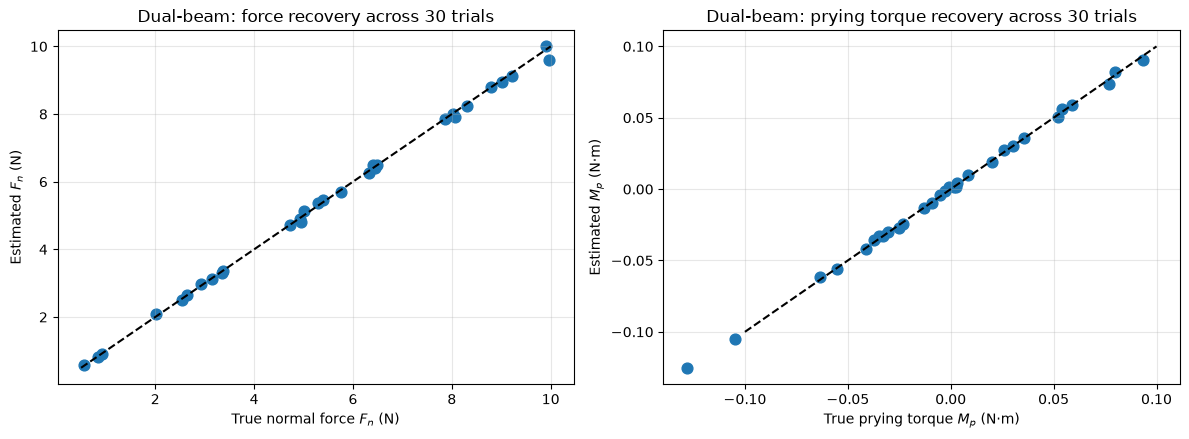

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Dual-beam gripper: 2 0/90 sensors per beam
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x1 = 0.003      # sensor 1 on each beam
x2 = 0.006      # sensor 2 on each beam
pivot = 0.002

w = 0.04        # beam spacing / gripper opening (m)

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain(F, x):
    """Bending strain tensor for one beam under force F (no prying inside a single beam)."""
    M = F * (x - pivot)
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x
    gamma_xy = 0.0
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    """4-resistor Wheatstone bridge output from surface strain tensor."""
    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# Search grid
Fn_grid = np.linspace(0.5, 10, 120)
Mp_grid = np.linspace(-0.2, 0.2, 140)
Fn_2d = Fn_grid[:, None]
Mp_2d = Mp_grid[None, :]

# Beam forces in terms of total normal force and prying torque
F_A = Fn_2d / 2 + Mp_2d / w
F_B = Fn_2d / 2 - Mp_2d / w

# Precompute 0/90 bridge outputs for all four sensors
# V_A1: beam A at x1, V_A2: beam A at x2, V_B1: beam B at x1, V_B2: beam B at x2
V_A1_grid = mems_bridge_output(*beam_strain(F_A, x1), orientation='0/90')
V_A2_grid = mems_bridge_output(*beam_strain(F_A, x2), orientation='0/90')
V_B1_grid = mems_bridge_output(*beam_strain(F_B, x1), orientation='0/90')
V_B2_grid = mems_bridge_output(*beam_strain(F_B, x2), orientation='0/90')


def estimate_load(V_A1m, V_A2m, V_B1m, V_B2m):
    """Find (Fn, Mp) that best reproduces the four measured bridge outputs."""
    error_map = (V_A1_grid - V_A1m)**2 + (V_A2_grid - V_A2m)**2 + (V_B1_grid - V_B1m)**2 + (V_B2_grid - V_B2m)**2
    idx = np.argmin(error_map)
    i, j = np.unravel_index(idx, error_map.shape)
    return Fn_grid[i], Mp_grid[j]


# ====== Single example (for comparison) ======
true_Fn = 5.0
true_Mp = 0.08
SNR = 50
rng = np.random.default_rng(7)

F_A_t = true_Fn / 2 + true_Mp / w
F_B_t = true_Fn / 2 - true_Mp / w

V_A1_clean = mems_bridge_output(*beam_strain(F_A_t, x1), orientation='0/90')
V_A2_clean = mems_bridge_output(*beam_strain(F_A_t, x2), orientation='0/90')
V_B1_clean = mems_bridge_output(*beam_strain(F_B_t, x1), orientation='0/90')
V_B2_clean = mems_bridge_output(*beam_strain(F_B_t, x2), orientation='0/90')

V_A1_meas = V_A1_clean + V_A1_clean / SNR * rng.normal()
V_A2_meas = V_A2_clean + V_A2_clean / SNR * rng.normal()
V_B1_meas = V_B1_clean + V_B1_clean / SNR * rng.normal()
V_B2_meas = V_B2_clean + V_B2_clean / SNR * rng.normal()

est_Fn, est_Mp = estimate_load(V_A1_meas, V_A2_meas, V_B1_meas, V_B2_meas)

print("Dual-beam gripper with 2 0/90 sensors per beam")
print(f"Beam forces: F_A = {F_A_t:.3f} N, F_B = {F_B_t:.3f} N")
print(f"Clean V_A1 = {V_A1_clean:.6e} V, V_A2 = {V_A2_clean:.6e} V")
print(f"Clean V_B1 = {V_B1_clean:.6e} V, V_B2 = {V_B2_clean:.6e} V")
print(f"True  Fn = {true_Fn:.3f} N,  estimated Fn = {est_Fn:.3f} N")
print(f"True  Mp = {true_Mp:.3f} N·m, estimated Mp = {est_Mp:.3f} N·m")


# ====== Repeat over 30 random load cases ======
n_trials = 30
SNR = 50
rng = np.random.default_rng(7)

# Keep the single example as trial 0 and add random cases
# Mp is generated so that both beam forces stay positive: |Mp| <= 0.8 * Fn * w / 2
F_true = np.array([true_Fn] + [rng.uniform(0.5, 10.0) for _ in range(n_trials - 1)])
M_true = np.array([true_Mp] + [rng.uniform(-0.8, 0.8) * F_true[k] * w / 2 for k in range(1, n_trials)])

F_est = np.zeros(n_trials)
M_est = np.zeros(n_trials)

for k in range(n_trials):
    Fn = F_true[k]
    Mp = M_true[k]

    F_A_t = Fn / 2 + Mp / w
    F_B_t = Fn / 2 - Mp / w

    V_A1_clean = mems_bridge_output(*beam_strain(F_A_t, x1), orientation='0/90')
    V_A2_clean = mems_bridge_output(*beam_strain(F_A_t, x2), orientation='0/90')
    V_B1_clean = mems_bridge_output(*beam_strain(F_B_t, x1), orientation='0/90')
    V_B2_clean = mems_bridge_output(*beam_strain(F_B_t, x2), orientation='0/90')

    V_A1_meas = V_A1_clean + V_A1_clean / SNR * rng.normal()
    V_A2_meas = V_A2_clean + V_A2_clean / SNR * rng.normal()
    V_B1_meas = V_B1_clean + V_B1_clean / SNR * rng.normal()
    V_B2_meas = V_B2_clean + V_B2_clean / SNR * rng.normal()

    F_est[k], M_est[k] = estimate_load(V_A1_meas, V_A2_meas, V_B1_meas, V_B2_meas)

F_err = F_est - F_true
M_err = M_est - M_true

print(f"\n{n_trials} trials, SNR = {SNR}")
print(f"Force  | mean error = {np.mean(F_err):.4f} N, std = {np.std(F_err):.4f} N, max |error| = {np.max(np.abs(F_err)):.4f} N")
print(f"Moment | mean error = {np.mean(M_err):.4f} N·m, std = {np.std(M_err):.4f} N·m, max |error| = {np.max(np.abs(M_err)):.4f} N·m")
print(f"Force within 10%  = {np.mean(np.abs(F_err / F_true) < 0.10):.1%}")
print(f"Force within 5%   = {np.mean(np.abs(F_err / F_true) < 0.05):.1%}")
print(f"Moment within 0.05 N·m = {np.mean(np.abs(M_err) < 0.05):.1%}")

# ====== Plots ======
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(F_true, F_est, s=60)
axes[0].plot([0.5, 10], [0.5, 10], 'k--')
axes[0].set_xlabel('True normal force $F_n$ (N)')
axes[0].set_ylabel('Estimated $F_n$ (N)')
axes[0].set_title('Dual-beam: force recovery across 30 trials')
axes[0].grid(alpha=0.3)

axes[1].scatter(M_true, M_est, s=60)
axes[1].plot([-0.1, 0.1], [-0.1, 0.1], 'k--')
axes[1].set_xlabel('True prying torque $M_p$ (N·m)')
axes[1].set_ylabel('Estimated $M_p$ (N·m)')
axes[1].set_title('Dual-beam: prying torque recovery across 30 trials')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Force + torsion (0/90 + 45/45)

The jaw can also put a **torsional torque $T$** on the beam, twisting it about the long axis and producing shear strain $\gamma_{xy}$ at the surface.

- A **0/90°** bridge is blind to shear, so it reports only the normal-force component.
- A **45/45°** bridge with `+45/−45/−45/+45` arms is shear-sensitive and rejects pure bending.

Together, one 0/90° bridge and one 45/45° bridge give two equations for two unknowns: $F_n$ and $T$.

V1 (0/90)  = -6.027028e-03 V  (force channel)
V2 (45/45) = -1.859652e-03 V  (force + torque channel)

True  Fn = 5.000 N,   estimated Fn = 4.971 N
True  T  = 0.020 N·m, estimated T  = 0.020 N·m


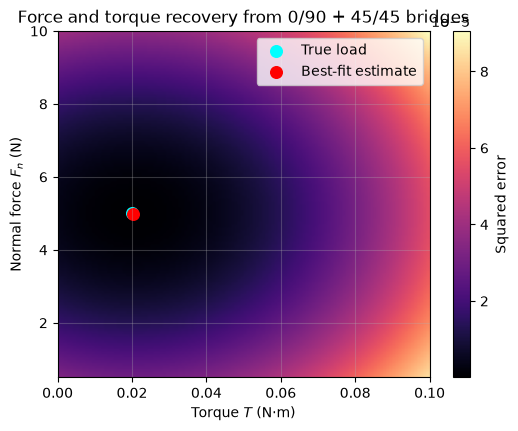

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Force + torsion inverse estimate
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_force = 0.018      # contact point where the normal force is applied
x1 = 0.003           # 0/90 sensor (force channel)
x2 = 0.006           # 45/45 sensor (force + torque channel)

R0 = 350
GF = 2.0
Vex = 3.3
G = 20               # MEMS strain amplification; can be tuned for a real flexure

# Torsion constants for a rectangular cross-section
G_shear = E / (2 * (1 + nu))
J_t = b * t**3 * (1/3 - 0.21 * (t/b) * (1 - (t/b)**4 / 12))


def beam_strain_tensor(Fn, T, x):
    """Return in-plane strain tensor at the surface for a given sensor position."""
    # Bending from normal force applied at x_force
    M = Fn * (x_force - x)
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x
    # Torsional shear strain (uniform along x for a uniform torque)
    if abs(T) < 1e-15:
        gamma_xy = 0.0
    else:
        tau_max = T * (3 + 1.8 * t/b) / (b * t**2)
        gamma_xy = tau_max / G_shear
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    """Physical Wheatstone bridge output from a 2D surface strain tensor."""
    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# True load to recover
true_Fn = 5.0      # N
true_T = 0.02      # N·m

# Generate clean sensor outputs
# V1 = 0/90 bridge: force only
# V2 = 45/45 bridge: force + torque
eps_x1, eps_y1, gamma1 = beam_strain_tensor(true_Fn, true_T, x1)
eps_x2, eps_y2, gamma2 = beam_strain_tensor(true_Fn, true_T, x2)

V1_true = mems_bridge_output(eps_x1, eps_y1, gamma1, orientation='0/90')
V2_true = mems_bridge_output(eps_x2, eps_y2, gamma2, orientation='45/45')

# Add measurement noise
SNR = 50
rng = np.random.default_rng(7)
V1_meas = V1_true + V1_true / SNR * rng.normal()
V2_meas = V2_true + V2_true / SNR * rng.normal()

print(f"V1 (0/90)  = {V1_meas:.6e} V  (force channel)")
print(f"V2 (45/45) = {V2_meas:.6e} V  (force + torque channel)")

# Grid search over Fn and T
Fn_grid = np.linspace(0.5, 10, 120)
T_grid = np.linspace(0.0, 0.1, 120)

best_error = np.inf
best_Fn = None
best_T = None

for Fn in Fn_grid:
    for T in T_grid:
        eps_x1p, eps_y1p, gamma1p = beam_strain_tensor(Fn, T, x1)
        eps_x2p, eps_y2p, gamma2p = beam_strain_tensor(Fn, T, x2)
        V1p = mems_bridge_output(eps_x1p, eps_y1p, gamma1p, orientation='0/90')
        V2p = mems_bridge_output(eps_x2p, eps_y2p, gamma2p, orientation='45/45')
        err = (V1p - V1_meas)**2 + (V2p - V2_meas)**2
        if err < best_error:
            best_error = err
            best_Fn = Fn
            best_T = T

print(f"\nTrue  Fn = {true_Fn:.3f} N,   estimated Fn = {best_Fn:.3f} N")
print(f"True  T  = {true_T:.3f} N·m, estimated T  = {best_T:.3f} N·m")

# ==============================
# Visualize the error surface
# ==============================
error_map = np.zeros((len(Fn_grid), len(T_grid)))
for i, Fn in enumerate(Fn_grid):
    for j, T in enumerate(T_grid):
        eps_x1p, eps_y1p, gamma1p = beam_strain_tensor(Fn, T, x1)
        eps_x2p, eps_y2p, gamma2p = beam_strain_tensor(Fn, T, x2)
        V1p = mems_bridge_output(eps_x1p, eps_y1p, gamma1p, orientation='0/90')
        V2p = mems_bridge_output(eps_x2p, eps_y2p, gamma2p, orientation='45/45')
        error_map[i, j] = (V1p - V1_meas)**2 + (V2p - V2_meas)**2

plt.figure(figsize=(6, 4.5))
im = plt.imshow(
    error_map,
    origin='lower',
    aspect='auto',
    extent=[T_grid[0], T_grid[-1], Fn_grid[0], Fn_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, label='Squared error')
plt.scatter(true_T, true_Fn, color='cyan', s=70, label='True load')
plt.scatter(best_T, best_Fn, color='red', s=70, label='Best-fit estimate')
plt.xlabel('Torque $T$ (N·m)')
plt.ylabel('Normal force $F_n$ (N)')
plt.title('Force and torque recovery from 0/90 + 45/45 bridges')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
